In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sympy
from sympy import Abs, And, Min, Max, Rational

# Cut a rope

When you take a rope of length 1, and cut it randomly into three pieces, what is the probability that the pieces can be used as sides of a triangle?

Generating the pieces can be done by selecting two random values $u, v \in [0, 1]$, the lengths of the pieces are then given by:
* $\min(u, v)$,
* $| u - v |$,
* $1 - \max(u, v)$.

## Derivation of the probability

When choosing $u, v \in [0, 1]$ randomly, you can impose $0 \le u < v < 1$ by renaming $u$ and $v$ if necessary.  The lengths of the pieces are given by:
* $u$,
* $v - u$,
* $1 - v$.

To form a triangle, three conditions must hold:
* $u < (v - u) + (1 - v)$, i.e., $u < \frac{1}{2}$,
* $v - u < u + (1 - v)$, i.e., $v - u < \frac{1}{2}$,
* $1 - v < u + (v - u)$, i.e., $1 - v < \frac{1}{2}$.

In other words, the length of all pieces has to be less than $1/2$.

Since $u$ and $v$ are chosen randomly and independently, they define a point in $[0, 1]^2$.

If the first length is greater than $1/2$, no triangle can be formed, so $u > 1/2$, but since $u < v$, $v > 1/2$ as well.  This describes $[1/2, 1]^2$, the upper-right quarter of $[0, 1]$.

If the third length is greater than $1/2$, again, no triangle can be formed.  Now $1 - v > 1/2$, so $v < 1/2$, and since $u < v$, also $u < 1/2$.  This describes $[0, 1/2]^2$, the lower-left quarter of $[0, 1]^2$.

Finally, if the second length is greater than $1/2$, $v - u > 1/2$, and this describes a triangle in the upper-left corner of $[0, 1]^2$ spanned by $(0, 1/2)$, $(0, 1)$ and $(1/2, 0)$ with an area of $1/8$.  As you sample randomly and uniformly from $[0, 1]^2$, and arbitrarily impose $u < v$, the reverse should also be considered for symmetry., so if $u > v$, then $u - v > 1/2$, and this defines a triangle in the lower-right corner of $[0, 1]^2$.  It is spanned by $(1/2, 0)$, $(1, 0)$ and $(1, 1/2)$, with an area of $1/8$.  The total area is $1/4$.

The remaining area of $[0, 1]^2$ is $1 - 3\frac{1}{4} = 1/4$, the probability you wanted to determine.

## Indicator function

This can also be computed directly using sympy by defining an indicator function on $[0, 1]^2$.

In [3]:
u, v = sympy.symbols('u v', real=True)

The condition that $u$ and $v$ will result in a triangle is given below.

In [4]:
condition = And(
    Min(u, v) < Rational(1, 2),
    Abs(u - v) < Rational(1, 2),
    1 - Max(u, v) < Rational(1, 2),
)

The indicator expression itself is piecewise, resulting in 1 if the condition holds, 0 otherwise.

In [5]:
expr = sympy.Piecewise(
    (1, condition),
    (0, True),
)

The indicator function can be visualized using numpy and matplotlib.

In [7]:
def indicator(U, V):
    return (
        (np.minimum(U, V) < 0.5) & \
        (np.abs(U - V) < 0.5) & \
        (1.0 - np.maximum(U, V) < 0.5)
    ).astype(int)

In [8]:
us = np.linspace(0.0, 1.0, 500)
vs = np.linspace(0.0, 1.0, 500)
U, V = np.meshgrid(us, vs)
Z = indicator(U, V)

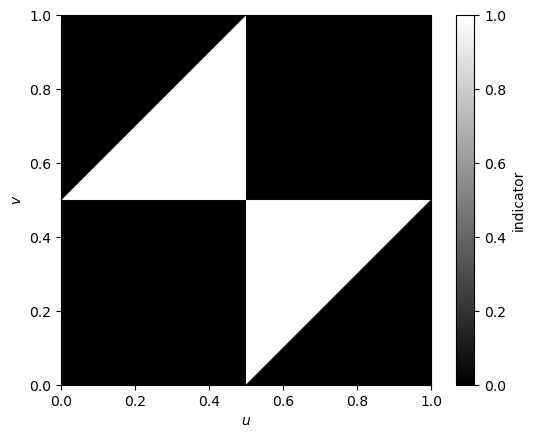

In [9]:
plt.imshow(Z, extent=(0.0, 1.0, 0.0, 1.0), origin='lower', aspect='equal', cmap='gray')
plt.xlabel(r'$u$')
plt.ylabel(r'$v$')
plt.colorbar(label='indicator')

## Probability

Now the probability is given by the double integral over $u \in [0, 1]$ and $v \in [0, 1]$.

In [6]:
sympy.integrate(expr, (v, 0, 1), (u, 0, 1))

1/4

The result is indeed $1/4$, as expected.

## Simulation

Generating the pieces can be done by selecting two random values, ensuring that they are sorted, and computing the lengths of the pieces.

In [32]:
def cut_rope(nr_tries):
    u = np.random.uniform(0.0, 1.0, size=nr_tries)
    v = np.random.uniform(0.0, 1.0, size=nr_tries)
    l1 = np.minimum(u, v)
    l2 = np.abs(v - u)
    l3 = 1.0 - np.maximum(u, v)
    return l1, l2, l3

The condition on the sides of a triangle is that the length of no sides exceeds the sum of the lengths of the two other sides.

In [33]:
def is_triagle(l1, l2, l3):
    return ((l1 < l2 + l3) & (l2 < l1 + l3) & (l3 < l1 + l2)).astype(np.int32)

Now you can count the number of cuts that produce the sides of a triangle.

In [39]:
def compute_probability(rope_cutter, nr_tries):
    l1, l2, l3 = rope_cutter(nr_tries)
    return np.sum(is_triagle(l1, l2, l3))/nr_tries

In [40]:
nr_tries = 100_000
compute_probability(cut_rope, nr_tries)

np.float64(0.24942)

This corresponds quite well to the expected probability.

# Cutting the rope differently

You can also consider a different procedure to cut the rope.
1. select $u \in [0, 1]$ randomly,
2. select $v \in [u, 1]$ randomly.

Now $u \le v$ by construction.  The conditions for the lengths are the same:
* $u < \frac{1}{2}$,
* $v - u < \frac{1}{2}$,
* $1 - v < \frac{1}{2}$.

## Derivation of the probability

From the second and the third condition, you get
$$
    \frac{1}{2} < v < u + \frac{1}{2}
$$

Hence the length of the interval from which $v$ can be selected is $1 - u$, while the length of the interval that would yield an acceptable value of $v$ is $u$.  Hence, the conditional probability of selecting $v$ given $u$ to get a triangle is
$$
    P(\mathrm{triangle} | u) = \frac{u}{1 - u}
$$
where $u < 1/2$.

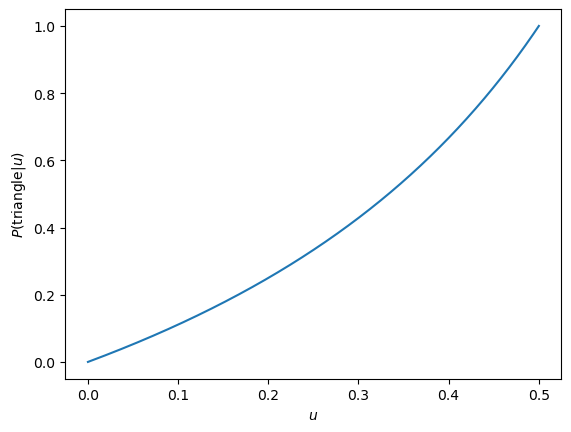

In [14]:
us = np.linspace(0.0, 0.5, 500)
plt.plot(us, us/(1.0 - us))
plt.xlabel(r'$u$')
plt.ylabel(r'$P(\mathrm{triangle} | u)$');

It is clear from the figure that small values of $u$ have a very low probability to result in a triangle, while values close to $1/2$ are very likely to yield triangles.

The probability of finding a triangle is then given by:
$$
    P(\mathrm{triangle}) = \int_{0}^{1/2} \frac{u}{1 - u} du
$$
since $P(\mathrm{triangle} | u > 1/2) = 0$.

In [15]:
expr2 = sympy.Piecewise(
    (u/(1 - u), u < Rational(1, 2)),
    (0, True),
)

In [17]:
p = sympy.integrate(expr2, (u, 0, 1))
p

-1/2 + log(2)

In [18]:
sympy.N(p)

0.193147180559945

## Simulation

Generating the pieces is now done according to the new rules.

In [35]:
def cut_rope_differently(nr_tries):
    u = np.random.uniform(0.0, 1.0, size=nr_tries)
    v = np.random.uniform(u, np.ones(nr_tries), size=nr_tries)
    l1 = u
    l2 = v - u
    l3 = 1.0 - v
    return l1, l2, l3

In [41]:
nr_tries = 100_000
compute_probability(cut_rope_differently, nr_tries)

np.float64(0.19401)

Again, the result corresponds well to the expected probability.